# YOLOv8 — Full Evaluation: Scratch vs Transfer Learning

Evaluates **both** trained models on the test set and prints a side-by-side comparison.

**Sections:**
1. Setup & constants
2. Shared evaluation helper functions
3. Run evaluation on Scratch model
4. Run evaluation on Transfer model
5. Side-by-side comparison table
6. Overlaid ROC curve plots (both models on same axes)

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.9 MB/s eta 0:00:00a 0:00:01


In [2]:
import os, json, shutil, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import torch

# ---- Global constants (must match preprocessing) ----
TOP5           = [1, 8, 7, 2, 9]
# 0 = Background; clothing classes are 1-indexed so YOLO class 0 = Background
category_names = ['Background', 'Short Sleeve Top', 'Trousers', 'Shorts', 'Long Sleeve Top', 'Skirt']
fg_names       = category_names[1:]   # foreground-only names for display
NUM_CLASSES    = len(category_names)  # 6

# Map DeepFashion2 cat_id → YOLO class index (1-indexed; 0 reserved for background)
cat_to_idx     = {cat_id: i + 1 for i, cat_id in enumerate(TOP5)}
idx_to_name    = {i: name for i, name in enumerate(category_names)}

DRIVE_SAVE     = "/kaggle/working/VR_Mini_Project-1"
os.makedirs(DRIVE_SAVE, exist_ok=True)

print(f"NUM_CLASSES : {NUM_CLASSES}  (0=Background, 1-5=clothing)")
print("cat_to_idx  :", cat_to_idx)

NUM_CLASSES : 6  (0=Background, 1-5=clothing)
cat_to_idx  : {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}


In [3]:
YOLO_ROOT = "/kaggle/working/yolo_dataset"
for split in ['train', 'val', 'test']:
    os.makedirs(f"{YOLO_ROOT}/{split}/images", exist_ok=True)
    os.makedirs(f"{YOLO_ROOT}/{split}/labels", exist_ok=True)


def process_yolo_split(filenames, src_img_dir, src_anno_dir,
                       dst_img_dir, dst_label_dir, cat_to_idx,
                       desc="Processing"):
    """Converts DeepFashion2 annotations to YOLO segmentation format.
    Class 0 = Background (explicit full-image rectangle polygon).
    Classes 1-5 = clothing items (1-indexed, normalised polygons).
    The background polygon is written first; clothing polygons follow.
    """
    skipped = 0
    for img_name in tqdm(filenames, desc=desc):
        img_path   = os.path.join(src_img_dir,  img_name)
        anno_path  = os.path.join(src_anno_dir,  img_name.replace('.jpg', '.json'))
        label_path = os.path.join(dst_label_dir, img_name.replace('.jpg', '.txt'))

        if not os.path.exists(anno_path):
            skipped += 1
            continue

        shutil.copy(img_path, os.path.join(dst_img_dir, img_name))

        with Image.open(img_path) as img:
            W, H = img.size

        with open(anno_path) as f:
            data = json.load(f)

        lines = []

        # ---- Class 0: Background — full image as a rectangle polygon ----
        # Four corners normalised: TL, TR, BR, BL
        lines.append("0 0.000000 0.000000 1.000000 0.000000 1.000000 1.000000 0.000000 1.000000")

        # ---- Classes 1-5: Clothing polygons ----
        for key in data:
            if not key.startswith("item"):
                continue
            cat_id = data[key]["category_id"]
            if cat_id not in cat_to_idx:
                continue

            yolo_cls = cat_to_idx[cat_id]   # 1-indexed
            polygons = data[key]["segmentation"]

            for poly in polygons:
                if len(poly) < 6:           # need at least 3 points
                    continue
                norm = []
                for i, coord in enumerate(poly):
                    if i % 2 == 0:          # X
                        norm.append(f"{max(0.0, min(1.0, coord / W)):.6f}")
                    else:                   # Y
                        norm.append(f"{max(0.0, min(1.0, coord / H)):.6f}")
                lines.append(f"{yolo_cls} " + " ".join(norm))

        with open(label_path, 'w') as f:
            f.write("\n".join(lines))

    print(f"  Skipped (missing annotation): {skipped}")


# ---- Collect file lists ----
# For train we replicate the 50 % subset used in classification
# (re-derive it here with the same seed so it matches)
all_train = sorted([f for f in os.listdir("/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/images") if f.endswith('.jpg')])
np.random.seed(42)
idx50 = np.random.choice(len(all_train), int(len(all_train) * 0.5), replace=False)
train_files = [all_train[i] for i in idx50]

val_files  = sorted([f for f in os.listdir("/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_val/images")  if f.endswith('.jpg')])
test_files = sorted([f for f in os.listdir("/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images") if f.endswith('.jpg')])

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

process_yolo_split(train_files, "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/images", "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_train/annos",
                   f"{YOLO_ROOT}/train/images", f"{YOLO_ROOT}/train/labels",
                   cat_to_idx, desc="Train")

process_yolo_split(val_files,   "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_val/images",   "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_val/annos",
                   f"{YOLO_ROOT}/val/images",   f"{YOLO_ROOT}/val/labels",
                   cat_to_idx, desc="Val")

process_yolo_split(test_files,  "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images",  "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/annos",
                   f"{YOLO_ROOT}/test/images",  f"{YOLO_ROOT}/test/labels",
                   cat_to_idx, desc="Test")

print("\nDataset construction complete.")

Train: 61273 | Val: 23741 | Test: 21627


Train: 100%|██████████| 61273/61273 [26:59<00:00, 37.85it/s]  


  Skipped (missing annotation): 0


Val: 100%|██████████| 23741/23741 [09:55<00:00, 39.83it/s]


  Skipped (missing annotation): 0


Test: 100%|██████████| 21627/21627 [07:58<00:00, 45.22it/s]

  Skipped (missing annotation): 0

Dataset construction complete.


In [4]:
# Write data.yaml — nc=6 (0=Background, 1-5=clothing)
yaml_content = f"""path: {YOLO_ROOT}
train: train/images
val:   val/images
test:  test/images

nc: {NUM_CLASSES}
names:
  0: Background
  1: {category_names[1]}
  2: {category_names[2]}
  3: {category_names[3]}
  4: {category_names[4]}
  5: {category_names[5]}
"""

yaml_path = f"{YOLO_ROOT}/data.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print("data.yaml written:")
print(yaml_content)

data.yaml written:
path: /kaggle/working/yolo_dataset
train: train/images
val:   val/images
test:  test/images

nc: 6
names:
  0: Background
  1: Short Sleeve Top
  2: Trousers
  3: Shorts
  4: Long Sleeve Top
  5: Skirt



In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — SETUP & CONSTANTS
# ═══════════════════════════════════════════════════════════════
import os, json as _json, cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_fscore_support
)
from ultralytics import YOLO

# ── Paths ──────────────────────────────────────────────────────
DRIVE_SAVE    = "/kaggle/working/VR_Mini_Project-1"
TEST_IMG_DIR  = "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/images"
TEST_ANNO_DIR = "/kaggle/input/datasets/sasank93/vr-mini-project-pruned/pruned_test/annos"
yaml_path     = f"{YOLO_ROOT}/data.yaml"

SCRATCH_WEIGHTS  = "/kaggle/input/datasets/akulanhith/you-only-look-once/scratch_best.pt"
TRANSFER_WEIGHTS = "/kaggle/input/datasets/akulanhith/you-only-look-once/best.pt"

# ── Class info ────────────────────────────────────────────────
TOP5           = [1, 8, 7, 2, 9]
category_names = ['Background', 'Short Sleeve Top', 'Trousers',
                  'Shorts', 'Long Sleeve Top', 'Skirt']
fg_names       = category_names[1:]
cat_to_idx     = {cat_id: i + 1 for i, cat_id in enumerate(TOP5)}
NUM_FG         = len(fg_names)            # 5

CONF_THRESH = 0.25
PALETTE     = ['#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4']

test_imgs = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.jpg')])
print(f"Test images : {len(test_imgs)}")
print(f"Scratch weights  exist: {os.path.exists(SCRATCH_WEIGHTS)}")
print(f"Transfer weights exist: {os.path.exists(TRANSFER_WEIGHTS)}")


Test images : 21627
Scratch weights  exist: True
Transfer weights exist: True


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — SHARED HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════

def polygon_to_mask(polygons, H, W):
    """Convert list of polygon coords to a binary mask (H x W)."""
    mask = np.zeros((H, W), dtype=np.uint8)
    for poly in polygons:
        pts = np.array(poly, dtype=np.float32).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)
    return mask


def evaluate_model(model, test_metrics, model_tag, save_dir):
    """
    Full evaluation of a YOLO segmentation model.

    Returns a dict of all scalar metrics so models can be compared.
    Saves ROC plots to save_dir with model_tag prefix.
    """
    results = {}
    os.makedirs(save_dir, exist_ok=True)

    box = test_metrics.box
    seg = test_metrics.seg

    # ── DETECTION native ──────────────────────────────────────
    results['det_map50']   = float(box.map50)
    results['det_map']     = float(box.map)
    results['det_mp']      = float(box.mp)
    results['det_mr']      = float(box.mr)

    # per-class AP50
    det_ap50_per_class = {}
    for i, name in enumerate(category_names):
        try:
            det_ap50_per_class[name] = float(box.ap50[i])
        except Exception:
            det_ap50_per_class[name] = float('nan')
    results['det_ap50_per_class'] = det_ap50_per_class

    # ── SEGMENTATION native ───────────────────────────────────
    results['seg_map50'] = float(seg.map50)
    results['seg_map']   = float(seg.map)
    results['seg_mp']    = float(seg.mp)
    results['seg_mr']    = float(seg.mr)

    mask_f1 = seg.f1
    results['seg_max_dice'] = float(mask_f1.max())
    results['seg_mid_dice'] = float(mask_f1[mask_f1.shape[0] // 2])

    seg_ap50_per_class = {}
    for i, name in enumerate(category_names):
        try:
            seg_ap50_per_class[name] = float(seg.ap50[i])
        except Exception:
            seg_ap50_per_class[name] = float('nan')
    results['seg_ap50_per_class'] = seg_ap50_per_class

    # ── Per-image inference for ROC / mIoU / Dice ────────────
    y_true_det   = {c: [] for c in range(1, NUM_FG + 1)}
    y_scores_det = {c: [] for c in range(1, NUM_FG + 1)}
    y_pred_det   = {c: [] for c in range(1, NUM_FG + 1)}

    y_true_seg   = {c: [] for c in range(1, NUM_FG + 1)}
    y_scores_seg = {c: [] for c in range(1, NUM_FG + 1)}
    y_pred_seg   = {c: [] for c in range(1, NUM_FG + 1)}

    iou_sum  = np.zeros(NUM_FG)
    dice_sum = np.zeros(NUM_FG)
    counts   = np.zeros(NUM_FG)

    for img_name in tqdm(test_imgs, desc=f"{model_tag} inference"):
        img_path  = os.path.join(TEST_IMG_DIR,  img_name)
        anno_path = os.path.join(TEST_ANNO_DIR, img_name.replace('.jpg', '.json'))

        with Image.open(img_path) as im:
            W, H = im.size

        gt_cls_present = set()
        gt_polys = {c: [] for c in range(1, NUM_FG + 1)}
        if os.path.exists(anno_path):
            with open(anno_path) as f:
                data = _json.load(f)
            for key in data:
                if not key.startswith('item'): continue
                cid = data[key]['category_id']
                if cid not in cat_to_idx: continue
                cls = cat_to_idx[cid]
                gt_polys[cls].extend(data[key]['segmentation'])
                gt_cls_present.add(cls)

        res = model(img_path, verbose=False, conf=0.001)[0]

        pred_conf_det  = {c: 0.0 for c in range(1, NUM_FG + 1)}
        pred_conf_seg  = {c: 0.0 for c in range(1, NUM_FG + 1)}
        pred_masks_cls = {c: np.zeros((H, W), dtype=np.uint8) for c in range(1, NUM_FG + 1)}

        if res.boxes is not None:
            for conf_t, cls_t in zip(res.boxes.conf, res.boxes.cls):
                c = int(cls_t.item())
                if 1 <= c <= NUM_FG:
                    pred_conf_det[c] = max(pred_conf_det[c], float(conf_t.item()))

        if res.masks is not None:
            for seg_m, cls_t, conf_t in zip(res.masks.data, res.boxes.cls, res.boxes.conf):
                c = int(cls_t.item())
                if c == 0 or c > NUM_FG: continue
                m = cv2.resize(seg_m.cpu().numpy(), (W, H))
                pred_masks_cls[c] = np.maximum(pred_masks_cls[c], (m > 0.5).astype(np.uint8))
                pred_conf_seg[c]  = max(pred_conf_seg[c], float(conf_t.item()))

        for c in range(1, NUM_FG + 1):
            ci = c - 1
            # detection ROC
            y_true_det[c].append(1 if c in gt_cls_present else 0)
            y_scores_det[c].append(pred_conf_det[c])
            y_pred_det[c].append(1 if pred_conf_det[c] >= CONF_THRESH else 0)

            # segmentation ROC
            y_true_seg[c].append(1 if c in gt_cls_present else 0)
            y_scores_seg[c].append(pred_conf_seg[c])
            y_pred_seg[c].append(1 if pred_conf_seg[c] >= CONF_THRESH else 0)

            # mIoU / Dice
            gt_mask   = polygon_to_mask(gt_polys[c], H, W)
            pred_mask = pred_masks_cls[c]
            if not (gt_mask.sum() == 0 and pred_mask.sum() == 0):
                counts[ci] += 1
                inter = (gt_mask & pred_mask).sum()
                union = (gt_mask | pred_mask).sum()
                iou_sum[ci]  += inter / (union + 1e-7)
                dice_sum[ci] += 2 * inter / (gt_mask.sum() + pred_mask.sum() + 1e-7)

    # ── Compute per-class det metrics ─────────────────────────
    det_aucs, det_p_list, det_r_list, det_f1_list = [], [], [], []
    det_fpr_tpr = {}
    for c, name in zip(range(1, NUM_FG + 1), fg_names):
        yt = np.array(y_true_det[c])
        ys = np.array(y_scores_det[c])
        yp = np.array(y_pred_det[c])
        p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='binary', zero_division=0)
        det_p_list.append(p); det_r_list.append(r); det_f1_list.append(f1)
        if yt.sum() > 0:
            fpr_, tpr_, _ = roc_curve(yt, ys)
            ra = auc(fpr_, tpr_)
            det_fpr_tpr[name] = (fpr_, tpr_)
        else:
            ra = float('nan')
        det_aucs.append(ra)

    yt_all = np.column_stack([y_true_det[c]  for c in range(1, NUM_FG + 1)])
    yp_all = np.column_stack([y_pred_det[c]  for c in range(1, NUM_FG + 1)])
    mac_p,  mac_r,  mac_f1,  _ = precision_recall_fscore_support(yt_all, yp_all, average='macro',  zero_division=0)
    mic_p,  mic_r,  mic_f1,  _ = precision_recall_fscore_support(yt_all, yp_all, average='micro',  zero_division=0)

    results['det_per_class']  = list(zip(fg_names, det_p_list, det_r_list, det_f1_list, det_aucs))
    results['det_macro_p']    = float(mac_p)
    results['det_macro_r']    = float(mac_r)
    results['det_macro_f1']   = float(mac_f1)
    results['det_micro_p']    = float(mic_p)
    results['det_micro_r']    = float(mic_r)
    results['det_micro_f1']   = float(mic_f1)
    results['det_mean_auc']   = float(np.nanmean(det_aucs))
    results['det_fpr_tpr']    = det_fpr_tpr
    results['det_aucs_dict']  = dict(zip(fg_names, det_aucs))

    # ── Compute per-class seg metrics ─────────────────────────
    valid_iou, valid_dice = [], []
    iou_per_class, dice_per_class = {}, {}
    for ci, name in enumerate(fg_names):
        if counts[ci] > 0:
            iou_c  = float(iou_sum[ci]  / counts[ci])
            dice_c = float(dice_sum[ci] / counts[ci])
        else:
            iou_c = dice_c = float('nan')
        iou_per_class[name]  = iou_c
        dice_per_class[name] = dice_c
        if not np.isnan(iou_c):
            valid_iou.append(iou_c)
            valid_dice.append(dice_c)

    results['seg_iou_per_class']  = iou_per_class
    results['seg_dice_per_class'] = dice_per_class
    results['seg_macro_miou']     = float(np.mean(valid_iou))
    results['seg_macro_dice']     = float(np.mean(valid_dice))

    seg_aucs, seg_p_list, seg_r_list, seg_f1_list = [], [], [], []
    seg_fpr_tpr = {}
    for c, name in zip(range(1, NUM_FG + 1), fg_names):
        yt = np.array(y_true_seg[c])
        ys = np.array(y_scores_seg[c])
        yp = np.array(y_pred_seg[c])
        p, r, f1, _ = precision_recall_fscore_support(yt, yp, average='binary', zero_division=0)
        seg_p_list.append(p); seg_r_list.append(r); seg_f1_list.append(f1)
        if yt.sum() > 0:
            fpr_, tpr_, _ = roc_curve(yt, ys)
            ra = auc(fpr_, tpr_)
            seg_fpr_tpr[name] = (fpr_, tpr_)
        else:
            ra = float('nan')
        seg_aucs.append(ra)

    yt_all_s = np.column_stack([y_true_seg[c]  for c in range(1, NUM_FG + 1)])
    yp_all_s = np.column_stack([y_pred_seg[c]  for c in range(1, NUM_FG + 1)])
    mac_ps, mac_rs, mac_f1s, _ = precision_recall_fscore_support(yt_all_s, yp_all_s, average='macro',  zero_division=0)
    mic_ps, mic_rs, mic_f1s, _ = precision_recall_fscore_support(yt_all_s, yp_all_s, average='micro',  zero_division=0)

    results['seg_per_class']  = list(zip(fg_names, seg_p_list, seg_r_list, seg_f1_list, seg_aucs))
    results['seg_macro_p']    = float(mac_ps)
    results['seg_macro_r']    = float(mac_rs)
    results['seg_macro_f1']   = float(mac_f1s)
    results['seg_micro_p']    = float(mic_ps)
    results['seg_micro_r']    = float(mic_rs)
    results['seg_micro_f1']   = float(mic_f1s)
    results['seg_mean_auc']   = float(np.nanmean(seg_aucs))
    results['seg_fpr_tpr']    = seg_fpr_tpr
    results['seg_aucs_dict']  = dict(zip(fg_names, seg_aucs))

    # ── Print full results ─────────────────────────────────────
    W_LINE = 68
    print("\n" + "═" * W_LINE)
    print(f"  MODEL: {model_tag}")
    print("═" * W_LINE)

    print("\n─── DETECTION (Bounding Box) ───────────────────────────────")
    print(f"  mAP@0.50           : {results['det_map50']:.4f}")
    print(f"  mAP@[0.5:0.95]     : {results['det_map']:.4f}")
    print(f"\nPer-class AP@0.50:")
    print(f"  {'Class':<22} {'AP@0.50':>8}")
    print("  " + "-" * 32)
    for name, ap in results['det_ap50_per_class'].items():
        print(f"  {name:<22} {ap:>8.4f}")
    print(f"\nPer-class Precision / Recall / F1 / AUC:")
    print(f"  {'Class':<22} {'P':>6} {'R':>6} {'F1':>6} {'AUC':>6}")
    print("  " + "-" * 52)
    for name, p, r, f1, ra in results['det_per_class']:
        print(f"  {name:<22} {p:>6.4f} {r:>6.4f} {f1:>6.4f} {ra:>6.4f}")
    print("  " + "-" * 52)
    print(f"  {'Macro avg':<22} {results['det_macro_p']:>6.4f} {results['det_macro_r']:>6.4f} {results['det_macro_f1']:>6.4f} {results['det_mean_auc']:>6.4f}")
    print(f"  {'Micro avg':<22} {results['det_micro_p']:>6.4f} {results['det_micro_r']:>6.4f} {results['det_micro_f1']:>6.4f}")

    print("\n─── SEGMENTATION (Mask) ────────────────────────────────────")
    print(f"  Mask mAP@0.50      : {results['seg_map50']:.4f}")
    print(f"  Mask mAP@[0.5:0.95]: {results['seg_map']:.4f}")
    print(f"  Max Dice (YOLO F1) : {results['seg_max_dice']:.4f}")
    print(f"\nPer-class Mask AP@0.50:")
    print(f"  {'Class':<22} {'MaskAP@0.50':>12}")
    print("  " + "-" * 36)
    for name, ap in results['seg_ap50_per_class'].items():
        print(f"  {name:<22} {ap:>12.4f}")
    print(f"\nPer-class mIoU & Dice:")
    print(f"  {'Class':<22} {'IoU':>8} {'Dice':>8}")
    print("  " + "-" * 42)
    for name in fg_names:
        iou_v  = results['seg_iou_per_class'][name]
        dice_v = results['seg_dice_per_class'][name]
        print(f"  {name:<22} {iou_v:>8.4f} {dice_v:>8.4f}")
    print("  " + "-" * 42)
    print(f"  {'Macro mIoU':<22} {results['seg_macro_miou']:>8.4f}")
    print(f"  {'Macro Dice':<22} {results['seg_macro_dice']:>8.4f}")
    print(f"\nPer-class Mask ROC metrics:")
    print(f"  {'Class':<22} {'P':>6} {'R':>6} {'F1':>6} {'AUC':>6}")
    print("  " + "-" * 52)
    for name, p, r, f1, ra in results['seg_per_class']:
        print(f"  {name:<22} {p:>6.4f} {r:>6.4f} {f1:>6.4f} {ra:>6.4f}")
    print("  " + "-" * 52)
    print(f"  {'Macro avg':<22} {results['seg_macro_p']:>6.4f} {results['seg_macro_r']:>6.4f} {results['seg_macro_f1']:>6.4f} {results['seg_mean_auc']:>6.4f}")
    print(f"  {'Micro avg':<22} {results['seg_micro_p']:>6.4f} {results['seg_micro_r']:>6.4f} {results['seg_micro_f1']:>6.4f}")

    # ── Save individual ROC plots ─────────────────────────────
    for task, fpr_tpr_dict, aucs_dict, title_suffix in [
        ('det', results['det_fpr_tpr'], results['det_aucs_dict'], 'Detection'),
        ('seg', results['seg_fpr_tpr'], results['seg_aucs_dict'], 'Segmentation'),
    ]:
        fig, ax = plt.subplots(figsize=(9, 7))
        for c, (name, color) in enumerate(zip(fg_names, PALETTE), start=1):
            if name not in fpr_tpr_dict: continue
            fpr_, tpr_ = fpr_tpr_dict[name]
            ax.plot(fpr_, tpr_, lw=2, color=color,
                    label=f'{name} (AUC={aucs_dict[name]:.3f})')
        ax.plot([0, 1], [0, 1], 'k--', label='Random')
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title(f'YOLOv8 {title_suffix} ROC — {model_tag}', fontsize=14)
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        save_path = os.path.join(save_dir, f"{model_tag}_{task}_roc.png")
        plt.savefig(save_path, dpi=150)
        plt.show()
        print(f"Saved → {save_path}")

    return results


print("Helper functions defined. Ready to evaluate.")


Helper functions defined. Ready to evaluate.


Loading scratch model...
Running val() on test split...
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2020.5±815.2 MB/s, size: 77.4 KB)
val: Scanning /kaggle/working/yolo_dataset/test/labels... 21627 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21627/21627 1.2Kit/s 18.0s<0.1s
val: /kaggle/working/yolo_dataset/test/images/000115.jpg: 2 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/000744.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/001652.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/001998.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/002603.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/003177.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_datase

Scratch inference: 100%|██████████| 21627/21627 [25:56<00:00, 13.90it/s]



════════════════════════════════════════════════════════════════════
  MODEL: Scratch
════════════════════════════════════════════════════════════════════

─── DETECTION (Bounding Box) ───────────────────────────────
  mAP@0.50           : 0.8543
  mAP@[0.5:0.95]     : 0.6778

Per-class AP@0.50:
  Class                   AP@0.50
  --------------------------------
  Background               0.9950
  Short Sleeve Top         0.8500
  Trousers                 0.8977
  Shorts                   0.8977
  Long Sleeve Top          0.6351
  Skirt                    0.8505

Per-class Precision / Recall / F1 / AUC:
  Class                       P      R     F1    AUC
  ----------------------------------------------------
  Short Sleeve Top       0.7775 0.9409 0.8514 0.9390
  Trousers               0.8984 0.9099 0.9041 0.9763
  Shorts                 0.8484 0.8833 0.8655 0.9685
  Long Sleeve Top        0.6854 0.8452 0.7570 0.9340
  Skirt                  0.7525 0.8445 0.7959 0.9383
  ------------

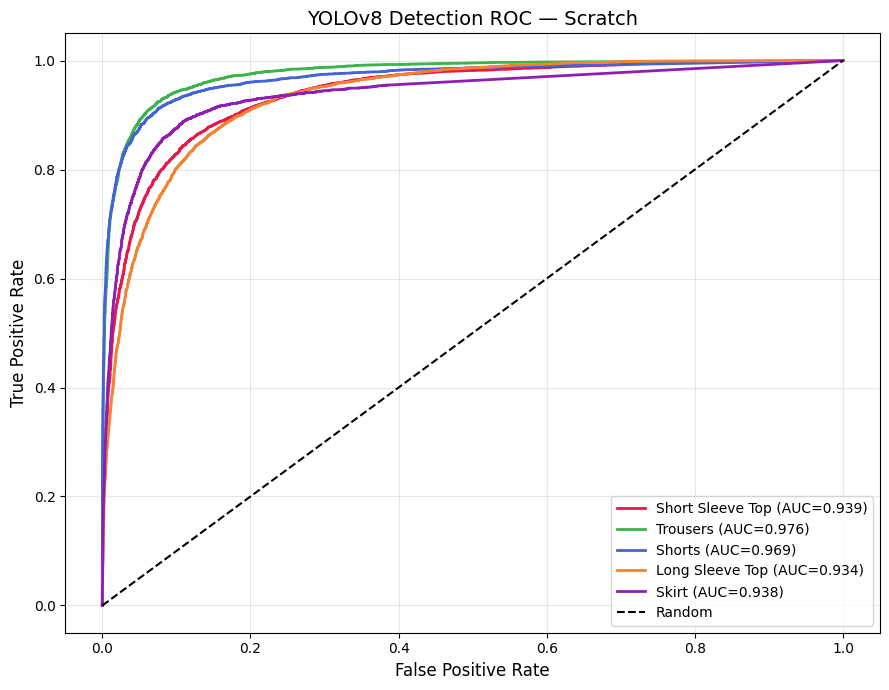

Saved → /kaggle/working/VR_Mini_Project-1/Scratch_det_roc.png


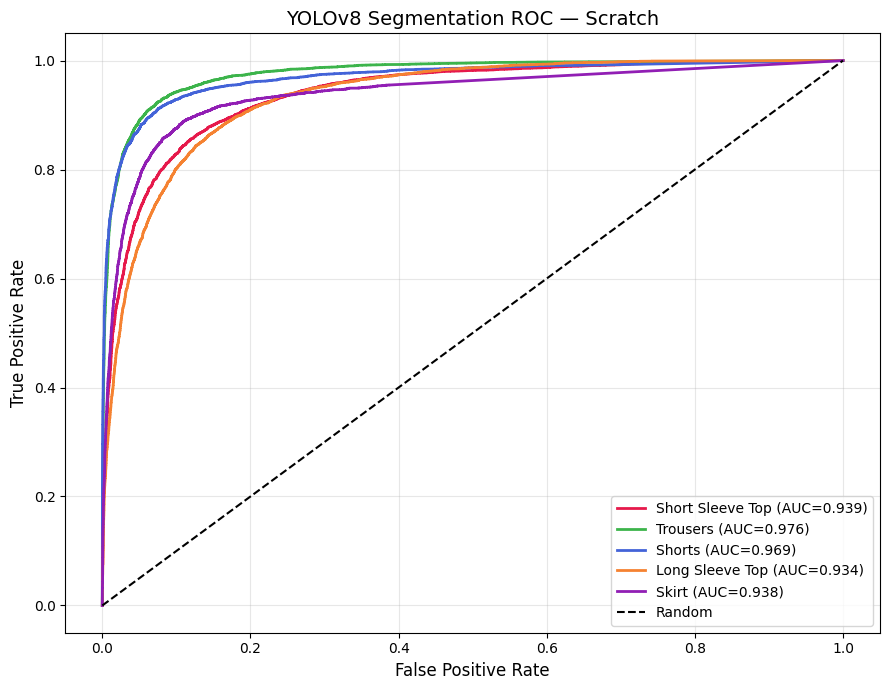

Saved → /kaggle/working/VR_Mini_Project-1/Scratch_seg_roc.png


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — EVALUATE SCRATCH MODEL
# ═══════════════════════════════════════════════════════════════
print("Loading scratch model...")
model_scratch   = YOLO(SCRATCH_WEIGHTS)

print("Running val() on test split...")
metrics_scratch = model_scratch.val(data=yaml_path, split='test', device=0, verbose=False)

results_scratch = evaluate_model(model_scratch, metrics_scratch,
                                 model_tag="Scratch",
                                 save_dir=DRIVE_SAVE)


Loading transfer model...
Running val() on test split...
Ultralytics 8.4.32 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,234 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1479.8±633.2 MB/s, size: 57.4 KB)
val: Scanning /kaggle/working/yolo_dataset/test/labels.cache... 21627 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 21627/21627 7.0Git/s 0.0s
val: /kaggle/working/yolo_dataset/test/images/000115.jpg: 2 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/000744.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/001652.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/001998.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/002603.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_dataset/test/images/003177.jpg: 1 duplicate labels removed
val: /kaggle/working/yolo_datas

Transfer inference: 100%|██████████| 21627/21627 [22:22<00:00, 16.10it/s]  



════════════════════════════════════════════════════════════════════
  MODEL: Transfer
════════════════════════════════════════════════════════════════════

─── DETECTION (Bounding Box) ───────────────────────────────
  mAP@0.50           : 0.8876
  mAP@[0.5:0.95]     : 0.7300

Per-class AP@0.50:
  Class                   AP@0.50
  --------------------------------
  Background               0.9950
  Short Sleeve Top         0.8831
  Trousers                 0.9124
  Shorts                   0.9168
  Long Sleeve Top          0.7252
  Skirt                    0.8933

Per-class Precision / Recall / F1 / AUC:
  Class                       P      R     F1    AUC
  ----------------------------------------------------
  Short Sleeve Top       0.7883 0.9618 0.8664 0.9542
  Trousers               0.8895 0.9459 0.9168 0.9833
  Shorts                 0.8368 0.9163 0.8747 0.9772
  Long Sleeve Top        0.7111 0.8978 0.7936 0.9544
  Skirt                  0.7865 0.8767 0.8291 0.9479
  -----------

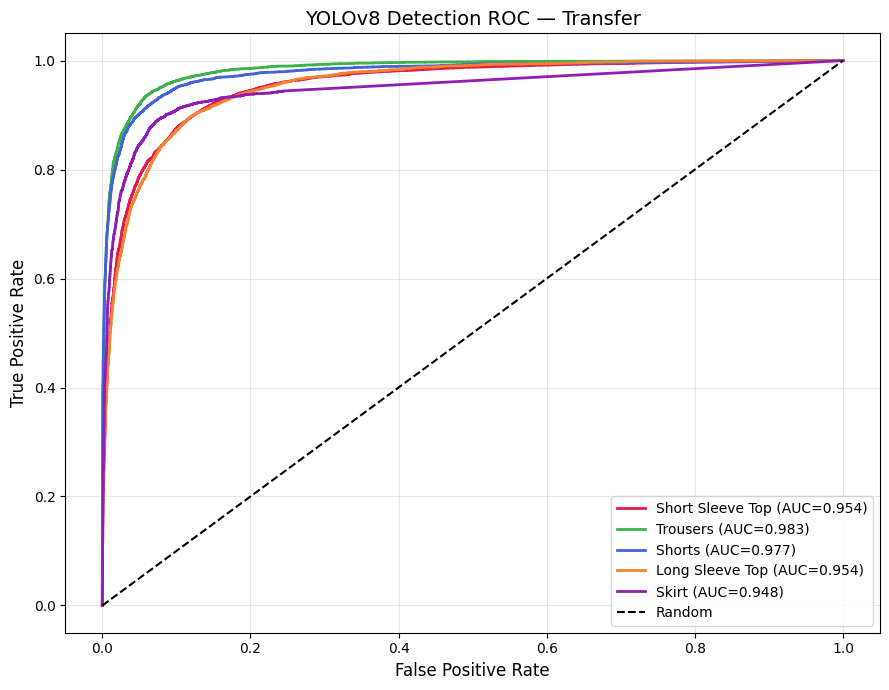

Saved → /kaggle/working/VR_Mini_Project-1/Transfer_det_roc.png


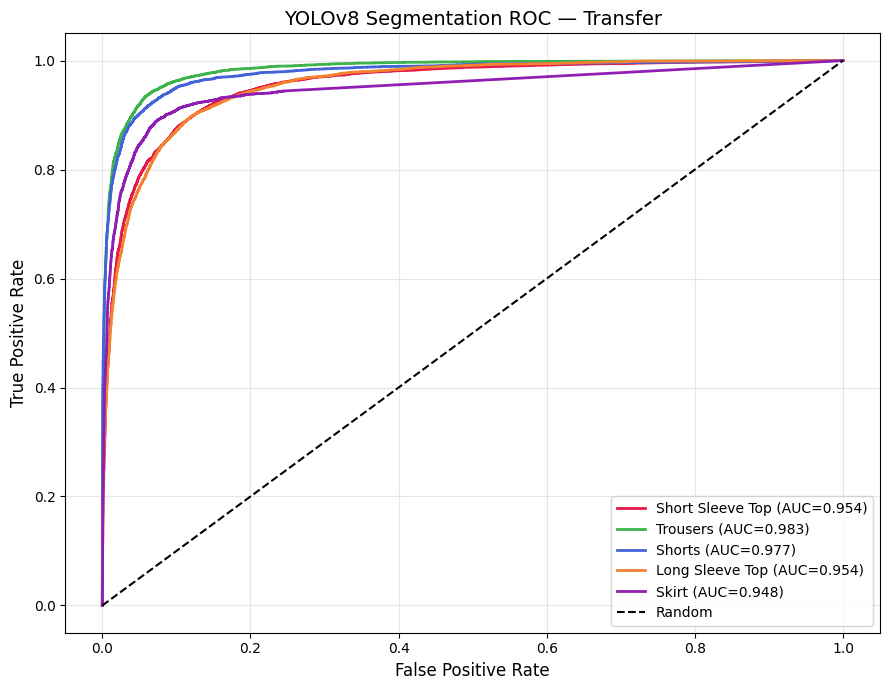

Saved → /kaggle/working/VR_Mini_Project-1/Transfer_seg_roc.png


In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — EVALUATE TRANSFER LEARNING MODEL
# ═══════════════════════════════════════════════════════════════
print("Loading transfer model...")
model_transfer   = YOLO(TRANSFER_WEIGHTS)

print("Running val() on test split...")
metrics_transfer = model_transfer.val(data=yaml_path, split='test', device=0, verbose=False)

results_transfer = evaluate_model(model_transfer, metrics_transfer,
                                  model_tag="Transfer",
                                  save_dir=DRIVE_SAVE)


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — SIDE-BY-SIDE COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════
S = results_scratch
T = results_transfer

def delta(s_val, t_val):
    """Show Transfer minus Scratch with +/- sign."""
    d = t_val - s_val
    return f"({'+' if d >= 0 else ''}{d:.4f})"

W = 72
print("═" * W)
print("  COMPARISON: Scratch  vs  Transfer Learning")
print("═" * W)
print(f"  {'Metric':<30} {'Scratch':>9} {'Transfer':>9} {'Delta':>10}")
print("  " + "-" * 62)

det_rows = [
    ("Det mAP@0.50",        'det_map50'),
    ("Det mAP@[0.5:0.95]",  'det_map'),
    ("Det Macro Precision",  'det_macro_p'),
    ("Det Macro Recall",     'det_macro_r'),
    ("Det Macro F1",         'det_macro_f1'),
    ("Det Micro F1",         'det_micro_f1'),
    ("Det Mean AUC",         'det_mean_auc'),
]
seg_rows = [
    ("Seg Mask mAP@0.50",   'seg_map50'),
    ("Seg Mask mAP@[0.5:95]",'seg_map'),
    ("Seg Macro mIoU",       'seg_macro_miou'),
    ("Seg Macro Dice",       'seg_macro_dice'),
    ("Seg Max Dice (YOLO)",  'seg_max_dice'),
    ("Seg Macro F1",         'seg_macro_f1'),
    ("Seg Micro F1",         'seg_micro_f1'),
    ("Seg Mean AUC",         'seg_mean_auc'),
]

print("\n  [ DETECTION ]")
for label, key in det_rows:
    sv, tv = S[key], T[key]
    print(f"  {label:<30} {sv:>9.4f} {tv:>9.4f} {delta(sv, tv):>10}")

print("\n  [ SEGMENTATION ]")
for label, key in seg_rows:
    sv, tv = S[key], T[key]
    print(f"  {label:<30} {sv:>9.4f} {tv:>9.4f} {delta(sv, tv):>10}")

print("\n  [ PER-CLASS mIoU ]")
print(f"  {'Class':<22} {'Scratch IoU':>12} {'Transfer IoU':>13} {'Delta':>10}")
print("  " + "-" * 60)
for name in fg_names:
    sv = S['seg_iou_per_class'][name]
    tv = T['seg_iou_per_class'][name]
    print(f"  {name:<22} {sv:>12.4f} {tv:>13.4f} {delta(sv, tv):>10}")

print("\n  [ PER-CLASS Dice ]")
print(f"  {'Class':<22} {'Scratch Dice':>12} {'Transfer Dice':>13} {'Delta':>10}")
print("  " + "-" * 60)
for name in fg_names:
    sv = S['seg_dice_per_class'][name]
    tv = T['seg_dice_per_class'][name]
    print(f"  {name:<22} {sv:>12.4f} {tv:>13.4f} {delta(sv, tv):>10}")

print("\n  [ PER-CLASS Det F1 ]")
print(f"  {'Class':<22} {'Scratch F1':>10} {'Transfer F1':>11} {'Delta':>10}")
print("  " + "-" * 56)
for (name, _, _, f1s, _), (_, _, _, f1t, _) in zip(S['det_per_class'], T['det_per_class']):
    print(f"  {name:<22} {f1s:>10.4f} {f1t:>11.4f} {delta(f1s, f1t):>10}")

print("\n  (Delta = Transfer − Scratch; positive = Transfer better)")
print("═" * W)


════════════════════════════════════════════════════════════════════════
  COMPARISON: Scratch  vs  Transfer Learning
════════════════════════════════════════════════════════════════════════
  Metric                           Scratch  Transfer      Delta
  --------------------------------------------------------------

  [ DETECTION ]
  Det mAP@0.50                      0.8543    0.8876  (+0.0333)
  Det mAP@[0.5:0.95]                0.6778    0.7300  (+0.0521)
  Det Macro Precision               0.7924    0.8024  (+0.0100)
  Det Macro Recall                  0.8848    0.9197  (+0.0349)
  Det Macro F1                      0.8348    0.8561  (+0.0214)
  Det Micro F1                      0.8425    0.8624  (+0.0198)
  Det Mean AUC                      0.9512    0.9634  (+0.0122)

  [ SEGMENTATION ]
  Seg Mask mAP@0.50                 0.6388    0.6714  (+0.0326)
  Seg Mask mAP@[0.5:95]             0.4391    0.4769  (+0.0378)
  Seg Macro mIoU                    0.3048    0.3526  (+0.0478)
  S

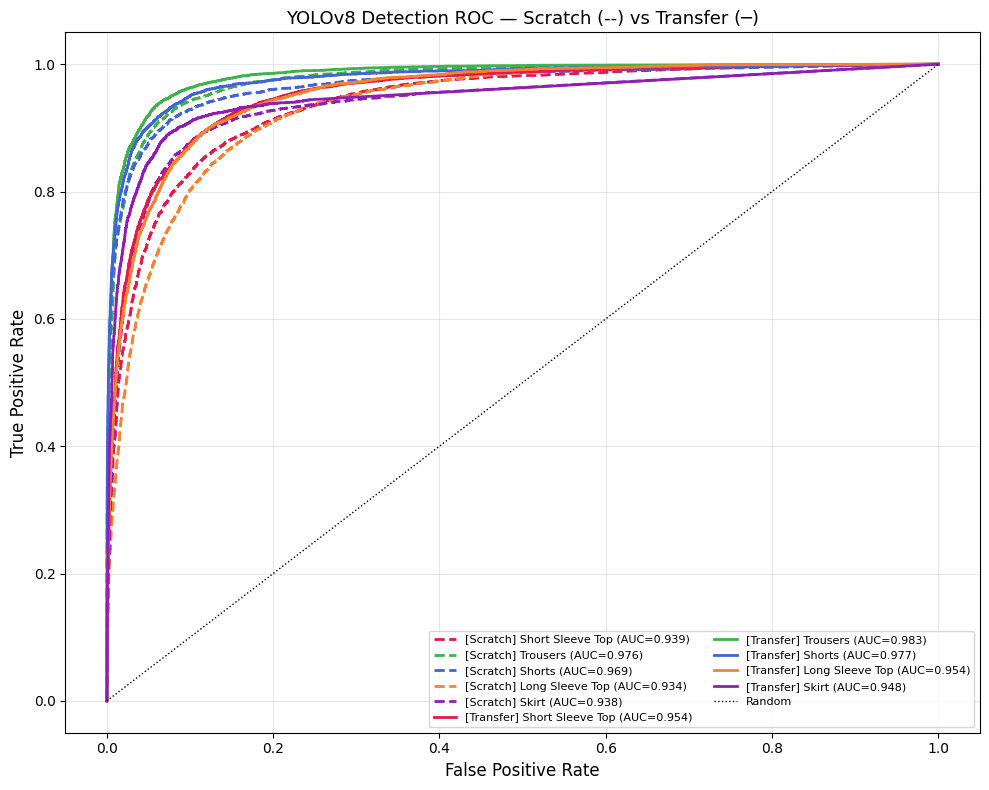

Saved → /kaggle/working/VR_Mini_Project-1/overlay_det_roc.png


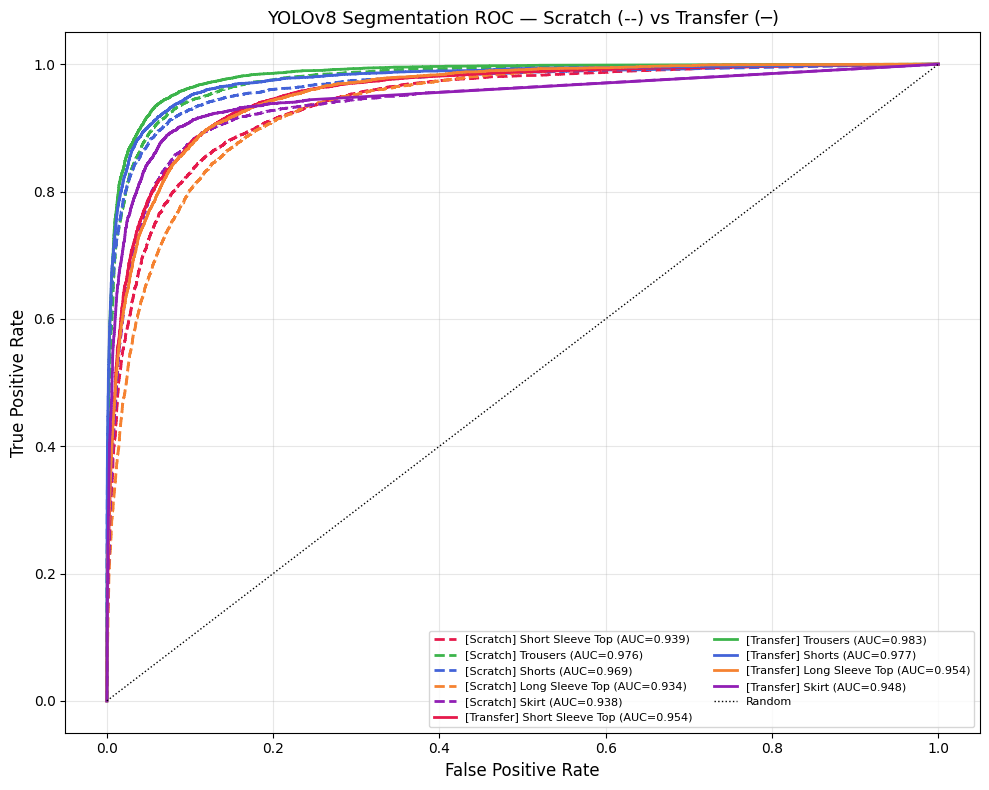

Saved → /kaggle/working/VR_Mini_Project-1/overlay_seg_roc.png


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — OVERLAID ROC PLOTS (both models on same axes)
# ═══════════════════════════════════════════════════════════════
LINE_STYLES = {'Scratch': '--', 'Transfer': '-'}
MODEL_RESULTS = {'Scratch': results_scratch, 'Transfer': results_transfer}

for task, title_suffix in [('det', 'Detection'), ('seg', 'Segmentation')]:
    fig, ax = plt.subplots(figsize=(10, 8))
    for model_tag, res in MODEL_RESULTS.items():
        fpr_tpr_dict = res[f'{task}_fpr_tpr']
        aucs_dict    = res[f'{task}_aucs_dict']
        ls           = LINE_STYLES[model_tag]
        for c, (name, color) in enumerate(zip(fg_names, PALETTE), start=1):
            if name not in fpr_tpr_dict: continue
            fpr_, tpr_ = fpr_tpr_dict[name]
            auc_val    = aucs_dict[name]
            ax.plot(fpr_, tpr_, lw=2, color=color, linestyle=ls,
                    label=f'[{model_tag}] {name} (AUC={auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k:', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'YOLOv8 {title_suffix} ROC — Scratch (--) vs Transfer (─)', fontsize=13)
    ax.legend(loc='lower right', fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    save_path = os.path.join(DRIVE_SAVE, f"overlay_{task}_roc.png")
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")
